# Terrorism Hotspots — EDA
## Context
 Analyze the data and draw conclusions on the distribution and nature of terrorist incidents recorded around the world
## Data Source
Global Terrorism Database (GTD) — https://www.start.umd.edu/gtd/
## Questions to answer
1. How has the number of terrorist activities changed over the years?
2. Are there certain regions where this trend is different from the global averages?
3. Is the number of incidents and the number of casualties correlated?
4. Can you spot any irregularities or outliers?
5. What are the most common methods of attacks? Does it differ in various regions or in time?
6. Plot the locations of attacks on a map to visualize their regional spread;
## Notebook Structure
1. Data Loading & Understanding
2. Data Cleaning
3. EDA — Temporal trends
4. EDA — Incidents vs Casualties
5. EDA — Attack methods
6. Geo visualization
7. Key Insights & Recommendations


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import ticker
from scipy.ndimage import label
from src.helpers import describe_missing, fmt_axis
from pathlib import Path

## 1. Load & Inspect

In [2]:
df = pd.read_csv("../data/raw/globalterrorismdb_0718dist.tar.bz2", compression="bz2")
df.info()
df.describe()


C:\Users\Olha\AppData\Local\Temp\ipykernel_13880\2436467889.py:1: DtypeWarning: Columns (5: approxdate, 7: resolution, 32: attacktype2_txt, 34: attacktype3_txt, 62: gsubname2, 63: gname3, 64: gsubname3, 77: claimmode2_txt, 80: claimmode3_txt, 91: weaptype3_txt, 93: weapsubtype3_txt, 95: weaptype4_txt, 97: weapsubtype4_txt, 115: divert, 116: kidhijcountry, 122: ransomnote) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/globalterrorismdb_0718dist.tar.bz2", compression="bz2")


<class 'pandas.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 136 entries, Unnamed: 0 to related
dtypes: float64(55), int64(23), str(58)
memory usage: 188.5 MB


,Unnamed: 0,eventid,iyear,imonth,iday,extended,country,region,latitude,longitude,...,ransomamt,ransomamtus,ransompaid,ransompaidus,hostkidoutcome,nreleased,INT_LOG,INT_IDEO,INT_MISC,INT_ANY
count,181691.000000,1.816910e+05,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,177135.000000,1.771340e+05,...,1.350000e+03,5.630000e+02,7.740000e+02,552.000000,10991.000000,10400.000000,181691.000000,181691.000000,181691.000000,181691.000000
mean,90845.000000,2.002705e+11,2002.638997,6.467277,15.505644,0.045346,131.968501,7.160938,23.498343,-4.586957e+02,...,3.172530e+06,5.784865e+05,7.179437e+05,240.378623,4.629242,-29.018269,-4.543731,-4.464398,0.090010,-3.945952
std,52449.818217,1.325957e+09,13.259430,3.388303,8.814045,0.208063,112.414535,2.933408,18.569242,2.047790e+05,...,3.021157e+07,7.077924e+06,1.014392e+07,2940.967293,2.035360,65.720119,4.543547,4.637152,0.568457,4.691325
min,0.000000,1.970000e+11,1970.000000,0.000000,0.000000,0.000000,4.000000,1.000000,-53.154613,-8.618590e+07,...,-9.900000e+01,-9.900000e+01,-9.900000e+01,-99.000000,1.000000,-99.000000,-9.000000,-9.000000,-9.000000,-9.000000
25%,45422.500000,1.991021e+11,1991.000000,4.000000,8.000000,0.000000,78.000000,5.000000,11.510046,4.545640e+00,...,0.000000e+00,0.000000e+00,-9.900000e+01,0.000000,2.000000,-99.000000,-9.000000,-9.000000,0.000000,-9.000000
50%,90845.000000,2.009022e+11,2009.000000,6.000000,15.000000,0.000000,98.000000,6.000000,31.467463,4.324651e+01,...,1.500000e+04,0.000000e+00,0.000000e+00,0.000000,4.000000,0.000000,-9.000000,-9.000000,0.000000,0.000000
75%,136267.500000,2.014081e+11,2014.000000,9.000000,23.000000,0.000000,160.000000,10.000000,34.685087,6.871033e+01,...,4.000000e+05,0.000000e+00,1.273412e+03,0.000000,7.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,181690.000000,2.017123e+11,2017.000000,12.000000,31.000000,1.000000,1004.000000,12.000000,74.633553,1.793667e+02,...,1.000000e+09,1.320000e+08,2.750000e+08,48000.000000,7.000000,2769.000000,1.000000,1.000000,1.000000,1.000000


## Reframe & Inspect

In [3]:
subset_cols = ["iyear", "country_txt", "region_txt", "city", "latitude",
               "longitude","success", "suicide", "attacktype1", "attacktype1_txt",
               "targtype1_txt", "targsubtype1_txt", "target1", "natlty1_txt", "gname",
               "gsubname", "nperps", "weaptype1_txt", "weapsubtype1_txt", "nkill", "nkillus"]
df_subset = df[subset_cols]
df_subset.info()
df_subset.describe()


<class 'pandas.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   iyear             181691 non-null  int64  
 1   country_txt       181691 non-null  str    
 2   region_txt        181691 non-null  str    
 3   city              181256 non-null  str    
 4   latitude          177135 non-null  float64
 5   longitude         177134 non-null  float64
 6   success           181691 non-null  int64  
 7   suicide           181691 non-null  int64  
 8   attacktype1       181691 non-null  int64  
 9   attacktype1_txt   181691 non-null  str    
 10  targtype1_txt     181691 non-null  str    
 11  targsubtype1_txt  171318 non-null  str    
 12  target1           181053 non-null  str    
 13  natlty1_txt       180132 non-null  str    
 14  gname             181691 non-null  str    
 15  gsubname          5890 non-null    str    
 16  nperps            110576 non-nu

,iyear,latitude,longitude,success,suicide,attacktype1,nperps,nkill,nkillus
count,181691.000000,177135.000000,1.771340e+05,181691.000000,181691.000000,181691.000000,110576.000000,171378.000000,117245.000000
mean,2002.638997,23.498343,-4.586957e+02,0.889598,0.036507,3.247547,-65.361154,2.403272,0.045981
std,13.259430,18.569242,2.047790e+05,0.313391,0.187549,1.915772,216.536633,11.545741,5.681854
min,1970.000000,-53.154613,-8.618590e+07,0.000000,0.000000,1.000000,-99.000000,0.000000,0.000000
25%,1991.000000,11.510046,4.545640e+00,1.000000,0.000000,2.000000,-99.000000,0.000000,0.000000
50%,2009.000000,31.467463,4.324651e+01,1.000000,0.000000,3.000000,-99.000000,0.000000,0.000000
75%,2014.000000,34.685087,6.871033e+01,1.000000,0.000000,3.000000,1.000000,2.000000,0.000000
max,2017.000000,74.633553,1.793667e+02,1.000000,1.000000,9.000000,25000.000000,1570.000000,1360.000000


### From description, we can assume:
1. Columns `longitude`, `latitude`, `city`, `nperps`, `nkill` should be inspected for nan and unpredictable values.
2. Column `nkill` need to be inspected for outliers.

In [4]:
print(df_subset.isna().sum())
print(df_subset.duplicated().sum())

iyear                    0
country_txt              0
region_txt               0
city                   435
latitude              4556
longitude             4557
success                  0
suicide                  0
attacktype1              0
attacktype1_txt          0
targtype1_txt            0
targsubtype1_txt     10373
target1                638
natlty1_txt           1559
gname                    0
gsubname            175801
nperps               71115
weaptype1_txt            0
weapsubtype1_txt     20768
nkill                10313
nkillus              64446
dtype: int64
15600


In [5]:
short_check_cols = ["iyear", "attacktype1_txt", "nkill", "success", "targtype1_txt", "nperps", "country_txt", "city"]

nan_coord = describe_missing(df_subset,
                             df_subset["latitude"].isna() | df_subset["longitude"].isna(),
                             "Missing coordinates",
                             short_check_cols)


Missing coordinates: 2.51% of dataset, 94.89% successful attacks rate, 47.83% with fatal casualties among successful
     iyear              attacktype1_txt  nkill  success  \
16    1970                      Unknown    1.0        1   
103   1970  Hostage Taking (Kidnapping)    0.0        0   
132   1970  Hostage Taking (Kidnapping)    0.0        1   
165   1970  Hostage Taking (Kidnapping)    0.0        1   
210   1970            Bombing/Explosion   36.0        1   

               targtype1_txt  nperps  country_txt     city  
16                  Military     1.0     Ethiopia  Unknown  
103     Government (General)     3.0        Spain  Unknown  
132      Journalists & Media     NaN     Ethiopia  Unknown  
165  Government (Diplomatic)     NaN     Ethiopia  Unknown  
210      Airports & Aircraft     NaN  Philippines  Cauayan  


Coordinates are not used to analyze trends over the years or the correlation between incidents and casualties; therefore, rows containing `NaN` for `lat/long` are fully valid here, and it was decided not to exclude them from the analysis.
However, to plot the locations of attacks on a map to visualize their regional spread, rows without coordinates cannot physically be plotted on the map; therefore, excluding them for this task is a technical necessity.


In [6]:
print(df_subset["latitude"].describe())
print(df_subset["longitude"].describe())
print(df_subset[df_subset["longitude"] < -180])
null_island = df_subset[(df_subset["latitude"] == 0) & (df_subset["longitude"] == 0)]
print(len(null_island))

count    177135.000000
mean         23.498343
std          18.569242
min         -53.154613
25%          11.510046
50%          31.467463
75%          34.685087
max          74.633553
Name: latitude, dtype: float64
count    1.771340e+05
mean    -4.586957e+02
std      2.047790e+05
min     -8.618590e+07
25%      4.545640e+00
50%      4.324651e+01
75%      6.871033e+01
max      1.793667e+02
Name: longitude, dtype: float64
       iyear country_txt                   region_txt              city  \
17658   1982   Nicaragua  Central America & Caribbean  Valle El Oregano   

        latitude   longitude  success  suicide  attacktype1 attacktype1_txt  \
17658  12.643985 -86185896.0        1        0            2   Armed Assault   

       ... targsubtype1_txt             target1 natlty1_txt    gname gsubname  \
17658  ...   Other Facility  tour of El Oregano   Nicaragua  Contras      NaN   

      nperps  weaptype1_txt                   weapsubtype1_txt nkill  nkillus  
17658    NaN       Firea

An abnormally large value for `longitude` was found in the description; upon checking, it turned out to be a typographical error — a missing decimal point. The coordinates fall within the actual range for the relevant country if the longitude value is divided by `1,000,000`.

In [7]:
df_subset["iyear"].unique()

array([1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980,
       1981, 1986, 1982, 1983, 1984, 1985, 1987, 1988, 1989, 1990, 1991,
       1992, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003,
       2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014,
       2015, 2016, 2017])

In [8]:
df_subset["region_txt"].unique()

<StringArray>
['Central America & Caribbean',               'North America',
              'Southeast Asia',              'Western Europe',
                   'East Asia',               'South America',
              'Eastern Europe',          'Sub-Saharan Africa',
  'Middle East & North Africa',       'Australasia & Oceania',
                  'South Asia',                'Central Asia']
Length: 12, dtype: str

In [9]:
nan_kills = describe_missing(df_subset,
                             df_subset["nkill"].isna(),
                             "Missing information about number of fatalities",
                             check_fatal=False)

Missing information about number of fatalities: 5.68% of dataset, 96.10% successful attacks rate
    iyear                 attacktype1_txt  nkill  success  \
3    1970               Bombing/Explosion    NaN        1   
4    1970  Facility/Infrastructure Attack    NaN        1   
15   1970               Bombing/Explosion    NaN        1   
34   1970  Facility/Infrastructure Attack    NaN        1   
95   1970                   Armed Assault    NaN        1   

              targtype1_txt  nperps         country_txt  
3   Government (Diplomatic)     NaN              Greece  
4   Government (Diplomatic)     NaN               Japan  
15     Government (General)     NaN  East Germany (GDR)  
34                   Police     NaN  East Germany (GDR)  
95                 Tourists     NaN              Jordan  


Almost `5.7%` of the `nkill` records contain no information. Following further investigation, it can be assumed that this is not due to an error during data collection. It is most likely that a terrorist attack took place, but no precise figures on the number of fatalities have been recorded. It was therefore decided to isolate a subset of the data and analyse it separately.

In [10]:
print(df_subset["nkill"].quantile([0.5, 0.9, 0.95, 0.99]))
q_99 = df_subset["nkill"].quantile( 0.99)
outliers =  df_subset[df_subset["nkill"] > q_99]
print(outliers[short_check_cols].sort_values("nkill").tail(10))
outliers_success_rate = outliers["success"].sum() / len(outliers) * 100
print(outliers_success_rate)

0.50     0.0
0.90     5.0
0.95    10.0
0.99    31.0
Name: nkill, dtype: float64
        iyear              attacktype1_txt   nkill  success  \
170198   2016  Hostage Taking (Kidnapping)   433.0        1   
136746   2014  Hostage Taking (Kidnapping)   517.0        1   
76347    2004                Armed Assault   518.0        1   
179671   2017            Bombing/Explosion   588.0        1   
133225   2014                Armed Assault   670.0        1   
136283   2014  Hostage Taking (Kidnapping)   953.0        1   
55934    1994                Armed Assault  1180.0        1   
73127    2001                    Hijacking  1383.0        1   
73126    2001                    Hijacking  1384.0        1   
133518   2014  Hostage Taking (Kidnapping)  1570.0        1   

                      targtype1_txt  nperps    country_txt              city  
170198  Private Citizens & Property   -99.0          Syria           Palmyra  
136746                     Military   -99.0          Syria          

Unlike the missing-value checks above, this outlier analysis is run once against a fixed threshold (q99) and isn't reused across other columns, so it wasn't abstracted into describe_missing/a shared helper — the added indirection wouldn't pay for itself for a single call site.
`1%` of events are characterised by a significantly higher number of fatalities than in most of the data. These records will be analysed separately as `high_impact_incidents`. The data includes both well-documented historical events (for example, presumably records of the aircraft hijackings on 11 September 2001) and cases where classification by attack type may not fully reflect the complexity of the incident.

In [11]:
print(df_subset["attacktype1_txt"].unique())
unknown_attacktype = describe_missing(df_subset,
                                      df_subset["attacktype1_txt"] == "Unknown",
                                      "Unknown attack type")


<StringArray>
[                      'Assassination',         'Hostage Taking (Kidnapping)',
                   'Bombing/Explosion',      'Facility/Infrastructure Attack',
                       'Armed Assault',                           'Hijacking',
                             'Unknown',                     'Unarmed Assault',
 'Hostage Taking (Barricade Incident)']
Length: 9, dtype: str
Unknown attack type: 4.00% of dataset, 82.67% successful attacks rate, 64.02% with fatal casualties among successful
     iyear attacktype1_txt  nkill  success targtype1_txt  nperps  country_txt
16    1970         Unknown    1.0        1      Military     1.0     Ethiopia
39    1970         Unknown    0.0        0      Military     NaN  Philippines
150   1970         Unknown    1.0        1      Military     NaN  Philippines
169   1970         Unknown    2.0        1      Military     NaN  Philippines
328   1970         Unknown    0.0        0      Military     NaN       Jordan


Unclassified attack vectors represent 4% of total entries. Given an 83% success rate within this group and a 64.02% fatality rate among those successes, these records were kept in the main dataset rather than dropped. This has no effect on Q1 (yearly trend) or Q2 (incidents–casualties correlation), since neither calculation uses attacktype1_txt; it will, however, appear as its own category in Q3 (attack methods by region/time) and should be interpreted as "method not recorded," not as a distinct attack type.

In [12]:
nan_perps = describe_missing(df_subset,
                             df_subset["nperps"].isna(),
                             "Missing number of terrorists participating in the incident")



Missing number of terrorists participating in the incident: 39.14% of dataset, 92.63% successful attacks rate, 41.53% with fatal casualties among successful
    iyear                 attacktype1_txt  nkill  success  \
0    1970                   Assassination    1.0        1   
2    1970                   Assassination    1.0        1   
3    1970               Bombing/Explosion    NaN        1   
4    1970  Facility/Infrastructure Attack    NaN        1   
10   1970               Bombing/Explosion    0.0        0   

                  targtype1_txt  nperps         country_txt  
0   Private Citizens & Property     NaN  Dominican Republic  
2           Journalists & Media     NaN         Philippines  
3       Government (Diplomatic)     NaN              Greece  
4       Government (Diplomatic)     NaN               Japan  
10                     Military     NaN       United States  


The majority of records missing the `nperps` feature were successful attacks. Since unrecorded perpetrator numbers are a well-documented domain pattern in real-world conflict data, these observations were stratified and evaluated independently.

In [13]:
sentinel_nperps = describe_missing(df_subset,
                                   df_subset["nperps"] == -99,
                                   "Sentinel value of terrorists participating in the incident")


Sentinel value of terrorists participating in the incident: 45.25% of dataset, 86.63% successful attacks rate, 51.60% with fatal casualties among successful
    iyear                 attacktype1_txt  nkill  success  \
5    1970                   Armed Assault    0.0        1   
7    1970               Bombing/Explosion    0.0        1   
11   1970  Facility/Infrastructure Attack    0.0        1   
13   1970  Facility/Infrastructure Attack    0.0        1   
14   1970  Facility/Infrastructure Attack    0.0        1   

           targtype1_txt  nperps    country_txt  
5                 Police   -99.0  United States  
7              Utilities   -99.0  United States  
11              Military   -99.0  United States  
13  Government (General)   -99.0  United States  
14              Business   -99.0  United States  


Approximately 45% of `nperps` entries contain the sentinel value `-99`, which the GTD uses as a coding convention for unknown values rather than representing a numerical anomaly. Because missing perpetrator counts carry structural information, these records will be retained. During the data cleaning phase, all `-99` values will be mapped to `NaN` and evaluated under a dedicated `nan_perps` feature.

## Data Understanding: Key Findings & Action Plan
#### Geospatial Data (`lat/long`):
 Missing coordinates will be kept for general analysis, but excluded only for map plotting. A typographical scaling error in `longitude` was identified and will be corrected during data cleaning.
#### Casualties (`nkill`):
Missing values (~5.7%) reflect real-world reporting gaps and will be analyzed separately. Extreme outliers (top 1%) will be isolated as `high_impact_incidents`.
#### Attack Types:
 Unclassified vectors (4%) will remain in the main dataset — they don't affect Q1/Q2, which don't use `attacktype1_txt`, but will appear as their own category in Q3 and should be read as "method not recorded," not a distinct attack type.
#### Perpetrators (`nperps`):
Missing counts are highly informative and will be evaluated via a dedicated subgroup. The GTD sentinel value -99 (~45% of entries) will be mapped to NaN and tracked using a `nan_perps` feature during data cleaning.

## Data Cleaning

In [14]:
df_clean = df_subset.copy()
anomaly_longitude = df_clean[df_clean["longitude"] < -180].index
df_clean.loc[anomaly_longitude, "longitude"] = df_clean.loc[anomaly_longitude, "longitude"] / 1000000

A typographical scaling error in `longitude` was fixed.

In [15]:
df_clean = df_clean[df_clean["nkill"].notna() & ~df_clean["nkill"].isin(outliers["nkill"])]

Isolated missing values and outliers in the casualties.

In [16]:
sentinel_cleaned = sentinel_nperps.copy()
sentinel_cleaned["nperps"] = sentinel_cleaned["nperps"].replace(-99, np.nan)
nan_perps = pd.concat([nan_perps, sentinel_cleaned], ignore_index=True)
df_clean = df_clean[df_clean["nperps"].notna() & ~df_clean["nperps"].isin(sentinel_nperps["nperps"])]

Replaced sentinels by `NaN` and added it to `nan_perps`. Separated missing `nperps`

In [17]:
df_clean.dtypes


iyear                 int64
country_txt             str
region_txt              str
city                    str
latitude            float64
longitude           float64
success               int64
suicide               int64
attacktype1           int64
attacktype1_txt         str
targtype1_txt           str
targsubtype1_txt        str
target1                 str
natlty1_txt             str
gname                   str
gsubname                str
nperps              float64
weaptype1_txt           str
weapsubtype1_txt        str
nkill               float64
nkillus             float64
dtype: object

## EDA - Temporal Trends
1. How has the number of terrorist activities changed over the years?
2. Are there certain regions where this trend is different from the global averages?

In [25]:
from cycler import cycler

BG, FG, ACCENT = "#16181a", "#a0aab2", "#ff4d4d"

def set_theme():
    sns.set_theme(style="dark", rc={
        "figure.dpi": 150,
        "figure.facecolor": BG,
        "axes.facecolor": BG,
        "savefig.facecolor": BG,
        "text.color": FG,
        "axes.labelcolor": FG,
        "axes.titlecolor": "white",
        "xtick.color": FG,
        "ytick.color": FG,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.spines.left": False,
        "axes.spines.right": False,
        "axes.spines.top": False,
        "axes.spines.bottom": False,
        "axes.grid": True,
        "axes.grid.axis": "y",
        "grid.color": "#ffffff",
        "grid.alpha": 0.2,
        "grid.linestyle": "--",
        "axes.prop_cycle": cycler(color=[ACCENT, "#4dc3ff", "#ffd24d", "#7dff4d"]),
    })

set_theme()

Created global theme for figures

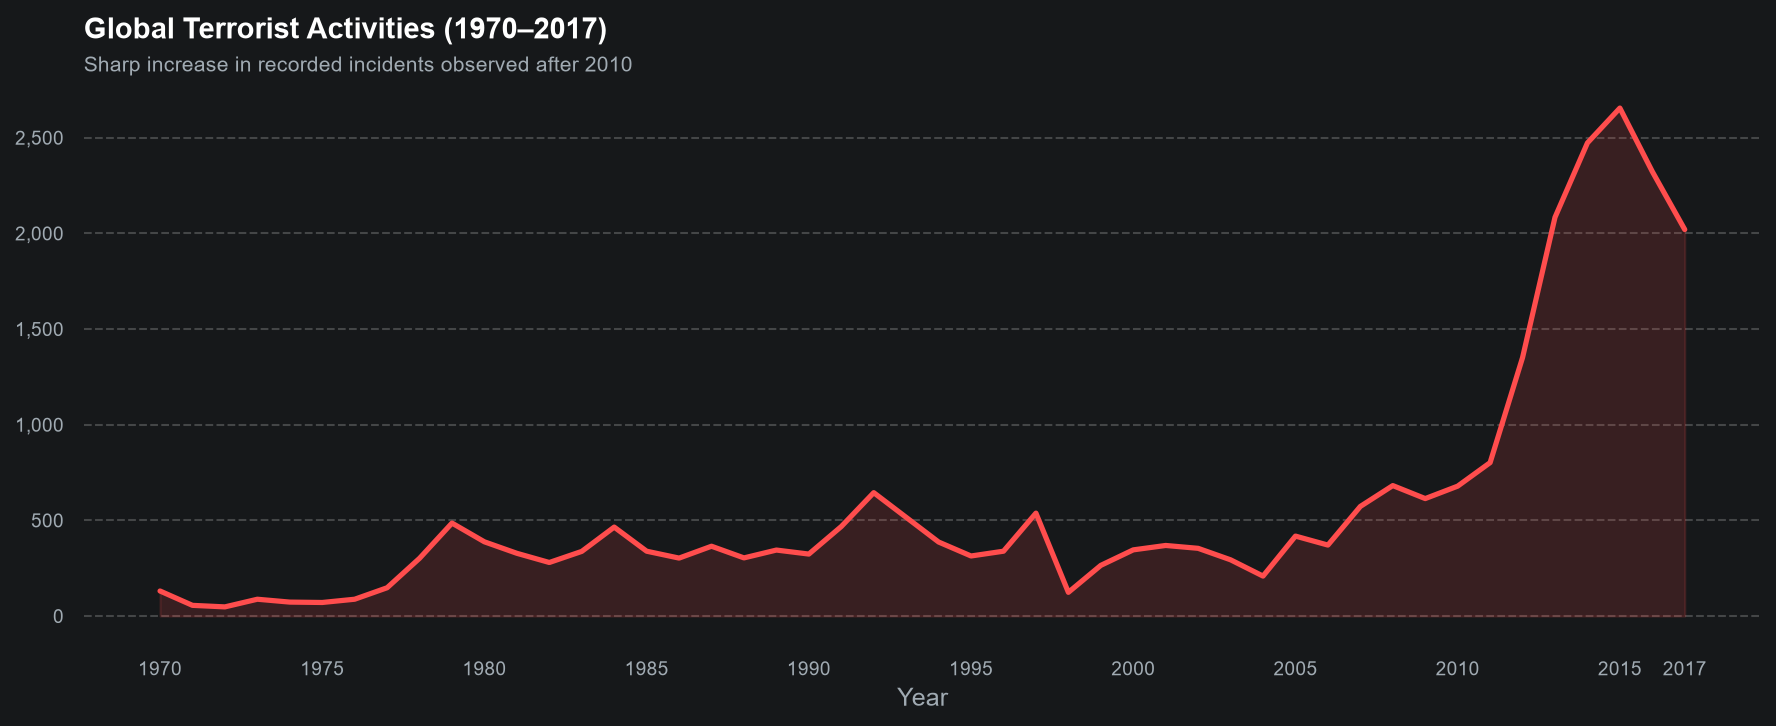

<Figure size 960x720 with 0 Axes>

In [26]:
global_trend = df_clean.groupby("iyear").size().reset_index(name="count")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    global_trend["iyear"], global_trend["count"], linewidth=2.5, color="#ff4d4d"
)
ax.fill_between(
    global_trend["iyear"], global_trend["count"], color="#ff4d4d", alpha=0.15
)
plt.title(
    "Global Terrorist Activities (1970–2017)\n", fontsize=14, fontweight="bold", loc="left"
)
ax.text(
    0, 1.02, "Increase after 2010 (partly reflects improved data collection from 2012)", transform=ax.transAxes, color="#a0aab2", fontsize=10
)
ax.set_xlabel("Year")
ax.set_ylabel("")
years = list(
    range(global_trend["iyear"].min(), global_trend["iyear"].max(), 5)
    ) + [global_trend["iyear"].max()]
ax.set_xticks(years)
fmt_axis(ax)

plt.tight_layout()
plt.show()

output_dir =  Path("..") / "outputs" / "figures"
output_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(output_dir / "Global Terrorist Activities (1970–2017).png", dpi=300)


When analyzing global trend of terrorist activities within years we can see sharp increase in recorded incidents after 2010, which is linked with the historical events.

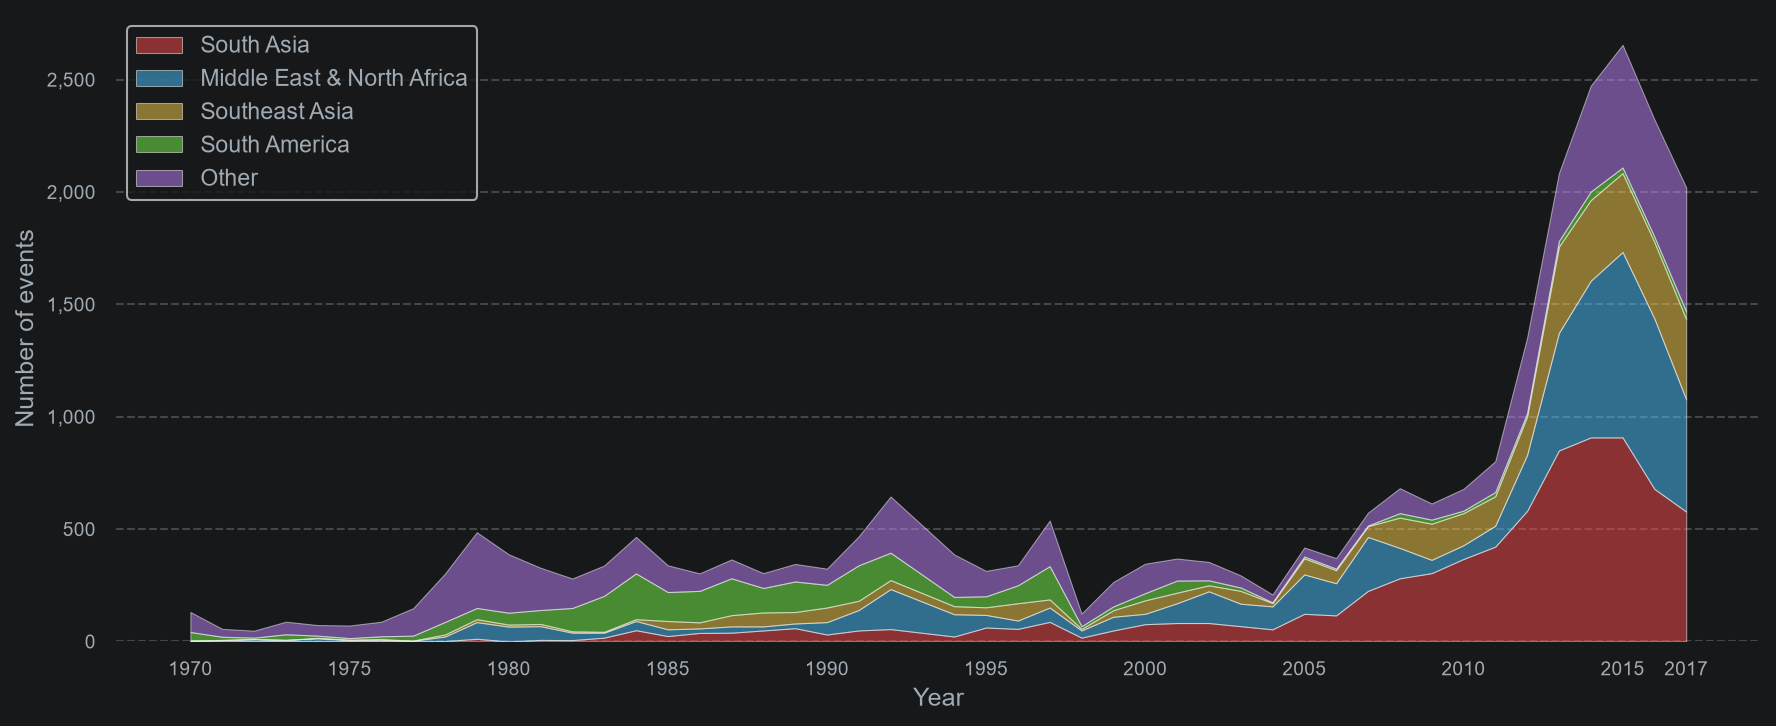

In [59]:
region_trend = df_clean.groupby(["iyear", "region_txt"]).size().reset_index(name="count")
top4 = region_trend.groupby("region_txt")["count"].sum().nlargest(4).index
region_trend["region_group"] = region_trend["region_txt"].where(region_trend["region_txt"].isin(top4), "Other")

wide = region_trend.groupby(["iyear", "region_group"])["count"].sum().unstack(fill_value=0)
order = wide.drop(columns="Other").sum().sort_values(ascending=False).index.tolist() + ["Other"]
wide = wide[order]

colors = [ACCENT, "#4dc3ff", "#ffd24d", "#7dff4d", "#c084fc"]

fig, ax = plt.subplots(figsize=(12, 5))
ax.stackplot(wide.index, wide.T.values, labels=wide.columns, colors=colors, alpha=0.5, edgecolor="#ffffff", linewidth=0.5)
ax.set_xlabel("Year")
ax.set_ylabel("Number of events")
ax.legend(loc="upper left")
ax.set_xticks(years)
fmt_axis(ax)

plt.tight_layout()
plt.show()

fig.savefig(output_dir / "Terrorist Activities within regions(1970–2017).png", dpi=300)


Regional aggregation of the data highlights a stark shift in the geography of terrorism. Following the global surge after 2010, the vast majority of incidents concentrated in South Asia and MENA. In contrast, the pre-2010 era (1970–2000s) experienced lower overall volumes with a more fragmented distribution, where South America and unclassified regions held a significantly larger share.

# EDA — Incidents vs Casualties
Is the number of incidents and the number of casualties correlated?